In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "boyaNautilus/"
filename = "Nautilus Data.xlsx"

dtype_dict = {
    "Device": str,  # Adjust with your actual column names
    "Date": str,
    "Data": str,
    "Depth": float,
    "OD": float,
    "EC": float,
    "Temp": float,
    "Chlor": float,
    "Batt12": float,
    "Batt13": float,
}

dataframes = pd.read_excel(os.path.join(path, filename), sheet_name=None, skiprows=1, dtype=dtype_dict)

for sheet_name, df in dataframes.items():
    if 'Time' in df.columns:
        df.rename(columns={'Time': 'Date'}, inplace=True)
        dataframes[sheet_name] = df[["Date", "Depth", "OD", "EC", "Temp", "Chlor"]]


In [5]:
dataframes["Urrutias"]

,Date,Depth,OD,EC,Temp,Chlor
0,2024-11-28 05:47:02,4.35,7.49,64.46,17.9,0.02
1,2024-11-28 05:46:33,4.99,7.54,58.76,17.9,0.06
2,2024-11-28 05:45:38,5.21,7.51,65.25,17.9,0.02
3,2024-11-27 23:42:29,4.94,7.96,61.24,18.1,0.05
4,2024-11-27 23:42:00,4.91,7.96,58.79,18.1,0.05
...,...,...,...,...,...,...
6315,2022-08-12 11:35:25,0.22,5.38,63.22,30.0,0.80
6316,2022-08-12 11:34:56,0.89,5.38,63.14,30.0,0.13
6317,2022-08-12 11:34:27,2.30,5.37,63.14,30.0,0.80
6318,2022-08-12 11:33:57,3.10,5.35,62.72,30.0,0.80


In [3]:
def remove_outliers(df):
    """Remove outliers from a dataframe using IQR."""
    # Select only numeric columns
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        df = df.dropna()
    return df

dataframes = {key: remove_outliers(df) for key, df in dataframes.items()}

In [4]:
for sheet_name, df in dataframes.items():
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        dataframes[sheet_name] = df.resample('D').mean().reset_index()

In [5]:
def replace_zeros_and_interpolate(df):
    """Replace zeros with NaN and perform linear interpolation."""
    #df.replace(0, np.nan, inplace=True)
    df.interpolate(method='linear', inplace=True)
    return df

dataframes_interpolados = {key: replace_zeros_and_interpolate(df.copy()) for key, df in dataframes.items()}

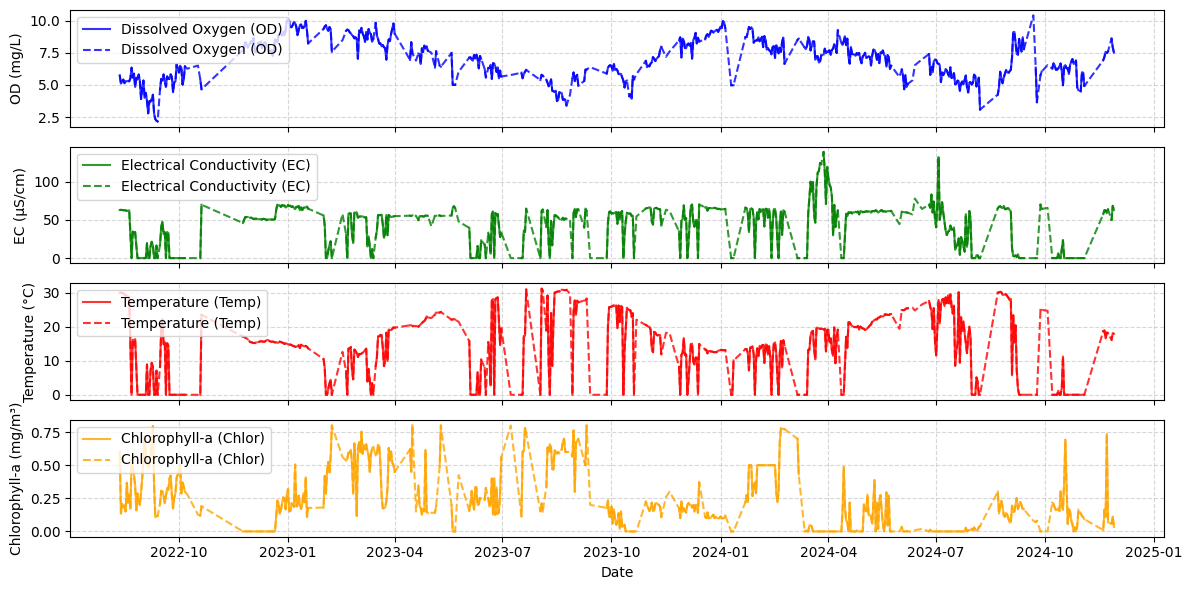

In [6]:
# Select one dataframe from the dictionary
df = dataframes["Urrutias"].copy()
df_interpolado = dataframes_interpolados["Urrutias"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
ec_idx = 1
temp_idx = 2
chlor_idx = 3

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

# Plot OD
axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen (OD)', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], label='Dissolved Oxygen (OD)', color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

# Plot EC
axes[ec_idx].plot(df.index, df['EC'], label='Electrical Conductivity (EC)', color='green', alpha=0.8)
axes[ec_idx].plot(df_interpolado.index, df_interpolado['EC'], label='Electrical Conductivity (EC)', color='green', alpha=0.8, linestyle = "--")
axes[ec_idx].set_ylabel('EC (µS/cm)')
axes[ec_idx].legend(loc='upper left')
axes[ec_idx].grid(True, linestyle='--', alpha=0.5)

# Plot Temp
axes[temp_idx].plot(df.index, df['Temp'], label='Temperature (Temp)', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], label='Temperature (Temp)', color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

# Plot Chlor
axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a (Chlor)', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], label='Chlorophyll-a (Chlor)', color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()


In [158]:
def summarize_dataframes(dataframes, columns):
    summary = {}
    for key, df in dataframes.items():
        if all(col in df.columns for col in columns):  # Ensure the required columns exist
            date_range = (df["Date"].min(), df["Date"].max())
            stats = {
                "Date Range": date_range,
                "Mean": round(df[columns].mean(), 2).to_dict(),
                "Min": df[columns].min().to_dict(),
                "Max": df[columns].max().to_dict(),
            }
            summary[key] = stats
    return summary

# Specify the columns of interest
columns_of_interest = ["OD", "EC", "Temp", "Chlor"]

# Call the function
summary_dict = summarize_dataframes(dataframes, columns_of_interest)

# Display the summary for each dataframe
for key, stats in summary_dict.items():
    print(f"Summary for {key}:")
    print(f"  Date Range: {stats['Date Range']}")
    print(f"  Mean: {stats['Mean']}")
    print(f"  Min: {stats['Min']}")
    print(f"  Max: {stats['Max']}")
    print()


Summary for Sur:
  Date Range: (Timestamp('2022-08-19 00:00:00'), Timestamp('2024-11-28 00:00:00'))
  Mean: {'OD': 7.48, 'EC': 41.53, 'Temp': 15.01, 'Chlor': 0.22}
  Min: {'OD': 3.713636363636364, 'EC': 0.0, 'Temp': 0.0, 'Chlor': 0.0}
  Max: {'OD': 10.687894736842106, 'EC': 115.65450000000001, 'Temp': 31.447058823529414, 'Chlor': 0.9}

Summary for Urrutias:
  Date Range: (Timestamp('2022-08-12 00:00:00'), Timestamp('2024-11-28 00:00:00'))
  Mean: {'OD': 6.99, 'EC': 42.9, 'Temp': 14.36, 'Chlor': 0.23}
  Min: {'OD': 2.1633333333333336, 'EC': 0.0, 'Temp': 0.0, 'Chlor': 0.0}
  Max: {'OD': 10.41, 'EC': 138.6, 'Temp': 31.175, 'Chlor': 0.8019999999999999}

Summary for Ribera:
  Date Range: (Timestamp('2022-08-23 00:00:00'), Timestamp('2024-11-28 00:00:00'))
  Mean: {'OD': 7.55, 'EC': 62.55, 'Temp': 22.52, 'Chlor': 0.17}
  Min: {'OD': 3.9071428571428575, 'EC': 31.02, 'Temp': 10.649999999999999, 'Chlor': 0.0}
  Max: {'OD': 10.786666666666667, 'EC': 85.29666666666667, 'Temp': 31.79285714285714, 

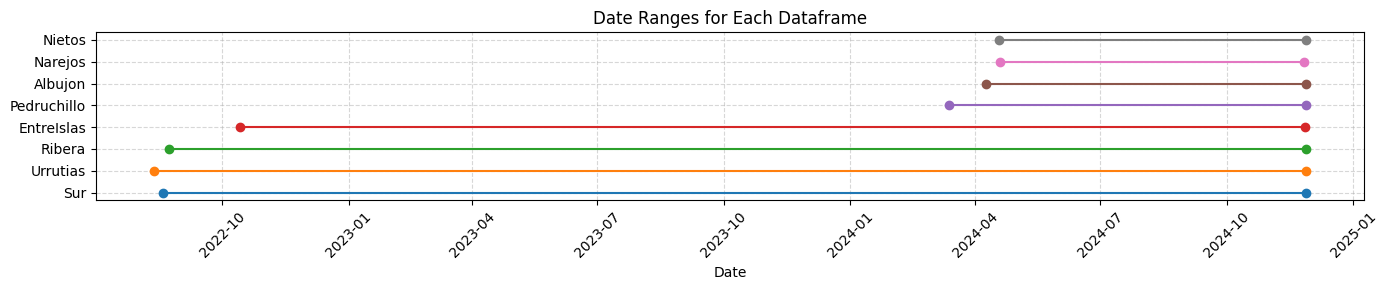

In [159]:
for key, df in dataframes_interpolados.items():
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])  # Convert to datetime if not already

def plot_date_ranges(dataframes):
    fig, ax = plt.subplots(figsize=(14, 3))
    for i, (key, df) in enumerate(dataframes.items()):
        if "Date" in df.columns:
            date_min = df["Date"].min()
            date_max = df["Date"].max()
            ax.plot([date_min, date_max], [i, i], label=key, marker='o')  # Plot a line with markers
            #ax.text(date_min, i, f" {date_min.date()}", va='center', fontsize=8)  # Add start date
            #ax.text(date_max, i, f" {date_max.date()}", va='center', fontsize=8)  # Add end date

    ax.set_yticks(range(len(dataframes)))
    ax.set_yticklabels(dataframes.keys())
    ax.set_xlabel("Date")
    ax.set_title("Date Ranges for Each Dataframe")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    #plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function
plot_date_ranges(dataframes_interpolados)

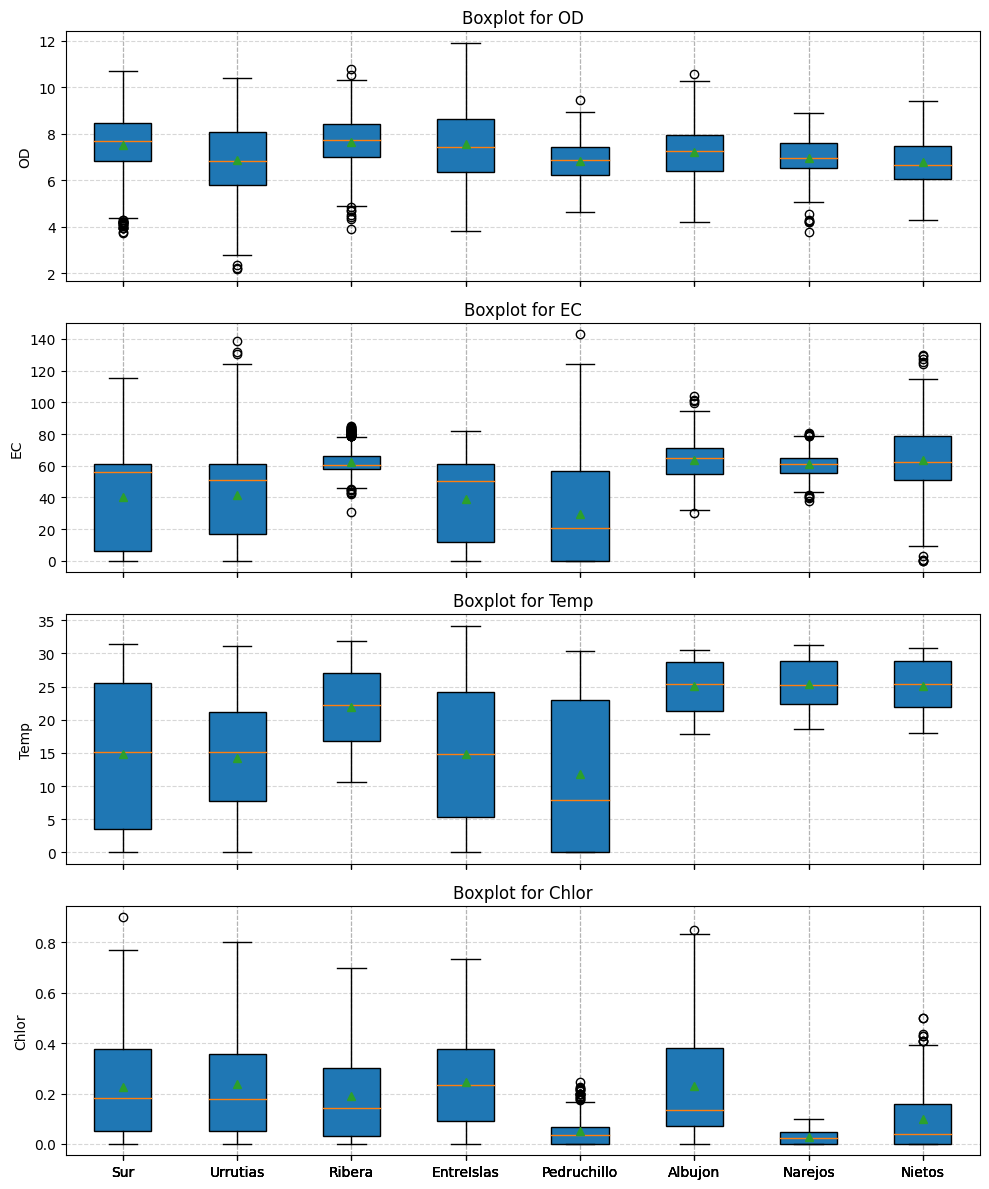

In [160]:
columns_of_interest = ["OD", "EC", "Temp", "Chlor"]

# Prepare data for each column
def prepare_boxplot_data(dataframes, column):
    data = []
    labels = []
    for key, df in dataframes.items():
        if column in df.columns:
            data.append(df[column].dropna())  # Drop NaN values
            labels.append(key)  # Use dataframe key as the label
    return data, labels

# Create boxplots for each column
fig, axes = plt.subplots(len(columns_of_interest), 1, figsize=(10, 3 * len(columns_of_interest)), sharex=True)

for i, column in enumerate(columns_of_interest):
    data, labels = prepare_boxplot_data(dataframes_interpolados, column)
    axes[i].boxplot(data, labels=labels, patch_artist=True, showmeans=True)
    axes[i].set_title(f"Boxplot for {column}")
    axes[i].set_ylabel(column)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()

### Comparación CTD8 - N2

In [8]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD8", "CTD2", "CTD7", "CTD10", "CTD6"]
# Diccionario para guardar dataframes
dataframes_boya_upct = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        # CARGAMOS SOLO CLOROFILA
        if nombre_variable in ["Clorofila","Oxigeno", "Salinidad", "Temperatura"]:
            dataframes_boya_upct[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)
        
for key, df in dataframes_boya_upct.items():
    df['Date'] = pd.to_datetime(df['Date'])
    dataframes_boya_upct[key] = df.set_index("Date") 

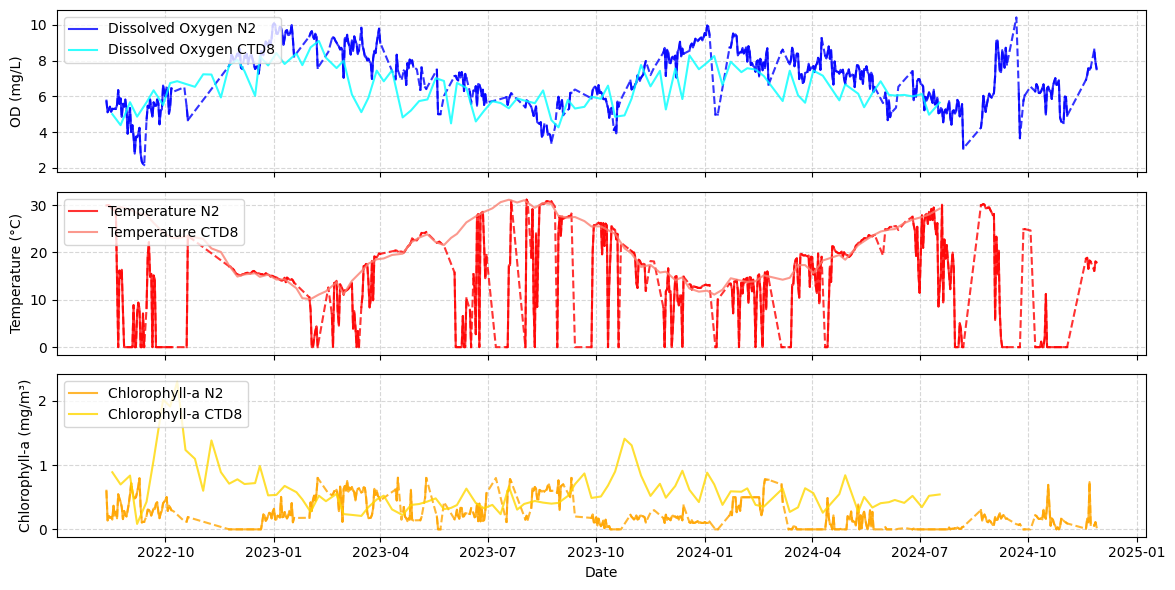

In [9]:
# Select one dataframe from the dictionary
df = dataframes["Urrutias"].copy()
df_interpolado = dataframes_interpolados["Urrutias"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
#ec_idx = 1
temp_idx = 1
chlor_idx = 2

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

start_date = df.index[0]
od_upct = dataframes_boya_upct["CTD8_Oxigeno"][dataframes_boya_upct["CTD8_Oxigeno"].index >= start_date]
# ec_upct = dataframes_boya_upct["CTD8_Salinidad"][dataframes_boya_upct["CTD8_Salinidad"].index >= start_date]
temp_upct = dataframes_boya_upct["CTD8_Temperatura"][dataframes_boya_upct["CTD8_Temperatura"].index >= start_date]
chlor_upct = dataframes_boya_upct["CTD8_Clorofila"][dataframes_boya_upct["CTD8_Clorofila"].index >= start_date]

axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen N2', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].plot(od_upct.index, od_upct["0.5"], label='Dissolved Oxygen CTD8', color='cyan', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

# axes[ec_idx].plot(df.index, df['EC'], label='Electrical Conductivity (EC)', color='green', alpha=0.8)
# axes[ec_idx].plot(df_interpolado.index, df_interpolado['EC'], label='Electrical Conductivity (EC)', color='green', alpha=0.8, linestyle = "--")
# axes[ec_idx].plot(ec_upct.index, od_upct["0.5"], label='Electrical Conductivity (EC)', color='limegreen', alpha=0.8)
# axes[ec_idx].set_ylabel('EC (µS/cm)')
# axes[ec_idx].legend(loc='upper left')
# axes[ec_idx].grid(True, linestyle='--', alpha=0.5)

axes[temp_idx].plot(df.index, df['Temp'], label='Temperature N2', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].plot(temp_upct.index, temp_upct["0.5"], label='Temperature CTD8', color='salmon', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a N2', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].plot(chlor_upct.index, chlor_upct["0.5"], label='Chlorophyll-a CTD8', color='gold', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.savefig("CTD8-N2.png", dpi=300)
plt.show()


### CTD2 - N5 (Narejos)

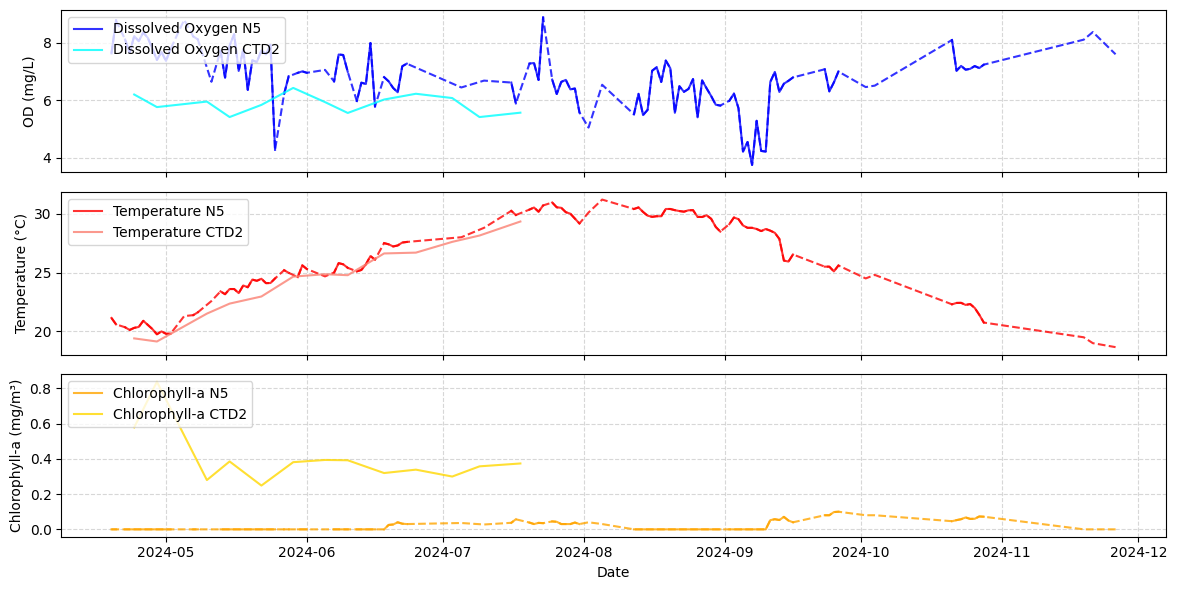

In [13]:
# Select one dataframe from the dictionary
df = dataframes["Narejos"].copy()
df_interpolado = dataframes_interpolados["Narejos"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
#ec_idx = 1
temp_idx = 1
chlor_idx = 2

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

start_date = df.index[0]
# end_date = dataframes_boya_upct["CTD2_Oxigeno"].index[-1]

#od_upct = dataframes_boya_upct["CTD2_Oxigeno"][(dataframes_boya_upct["CTD2_Oxigeno"].index >= start_date) & (dataframes_boya_upct["CTD2_Oxigeno"].index <= end_date)]
od_upct = dataframes_boya_upct["CTD2_Oxigeno"][dataframes_boya_upct["CTD2_Oxigeno"].index >= start_date]
# ec_upct = dataframes_boya_upct["CTD2_Salinidad"][dataframes_boya_upct["CTD2_Salinidad"].index >= start_date]
temp_upct = dataframes_boya_upct["CTD2_Temperatura"][dataframes_boya_upct["CTD2_Temperatura"].index >= start_date]
chlor_upct = dataframes_boya_upct["CTD2_Clorofila"][dataframes_boya_upct["CTD2_Clorofila"].index >= start_date]

axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen N5', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].plot(od_upct.index, od_upct["0.5"], label='Dissolved Oxygen CTD2', color='cyan', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

axes[temp_idx].plot(df.index, df['Temp'], label='Temperature N5', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].plot(temp_upct.index, temp_upct["0.5"], label='Temperature CTD2', color='salmon', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a N5', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].plot(chlor_upct.index, chlor_upct["0.5"], label='Chlorophyll-a CTD2', color='gold', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
# plt.savefig("CTD2-N5.png", dpi=300)
plt.show()

### CTD7 - N3 (Albujón)

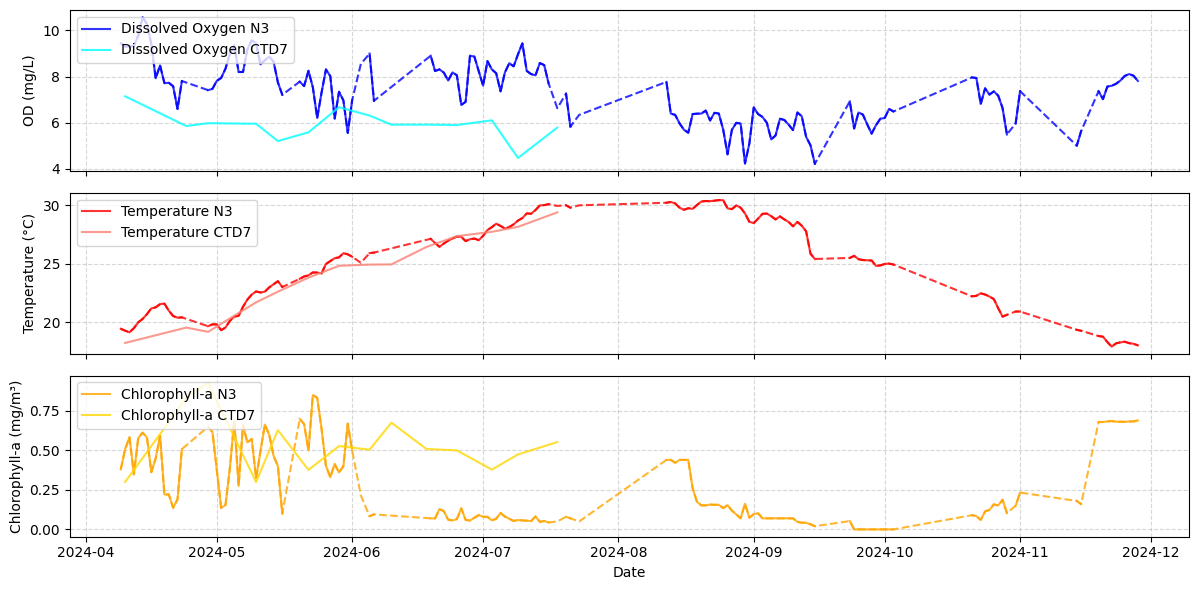

In [14]:
# Select one dataframe from the dictionary
df = dataframes["Albujon"].copy()
df_interpolado = dataframes_interpolados["Albujon"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
#ec_idx = 1
temp_idx = 1
chlor_idx = 2

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

start_date = df.index[0]
# end_date = dataframes_boya_upct["CTD7_Oxigeno"].index[-1]

#od_upct = dataframes_boya_upct["CTD7_Oxigeno"][(dataframes_boya_upct["CTD7_Oxigeno"].index >= start_date) & (dataframes_boya_upct["CTD7_Oxigeno"].index <= end_date)]
od_upct = dataframes_boya_upct["CTD7_Oxigeno"][dataframes_boya_upct["CTD7_Oxigeno"].index >= start_date]
# ec_upct = dataframes_boya_upct["CTD7_Salinidad"][dataframes_boya_upct["CTD7_Salinidad"].index >= start_date]
temp_upct = dataframes_boya_upct["CTD7_Temperatura"][dataframes_boya_upct["CTD7_Temperatura"].index >= start_date]
chlor_upct = dataframes_boya_upct["CTD7_Clorofila"][dataframes_boya_upct["CTD7_Clorofila"].index >= start_date]

axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen N3', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].plot(od_upct.index, od_upct["0.5"], label='Dissolved Oxygen CTD7', color='cyan', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

axes[temp_idx].plot(df.index, df['Temp'], label='Temperature N3', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].plot(temp_upct.index, temp_upct["0.5"], label='Temperature CTD7', color='salmon', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a N3', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].plot(chlor_upct.index, chlor_upct["0.5"], label='Chlorophyll-a CTD7', color='gold', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.savefig("CTD7-N3.png", dpi=300)
plt.show()

### CTD10 - N8 (Nietos)

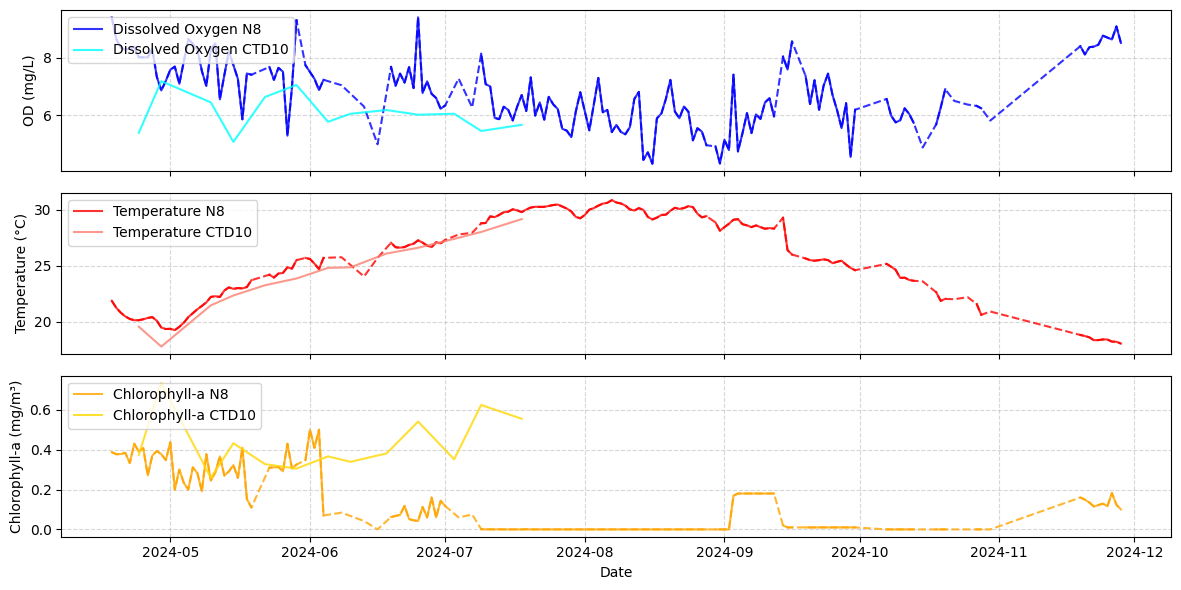

In [23]:
# Select one dataframe from the dictionary
df = dataframes["Nietos"].copy()
df_interpolado = dataframes_interpolados["Nietos"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
#ec_idx = 1
temp_idx = 1
chlor_idx = 2

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

start_date = df.index[0]
# end_date = dataframes_boya_upct["CTD10_Oxigeno"].index[-1]

#od_upct = dataframes_boya_upct["CTD10_Oxigeno"][(dataframes_boya_upct["CTD10_Oxigeno"].index >= start_date) & (dataframes_boya_upct["CTD10_Oxigeno"].index <= end_date)]
od_upct = dataframes_boya_upct["CTD10_Oxigeno"][dataframes_boya_upct["CTD10_Oxigeno"].index >= start_date]
# ec_upct = dataframes_boya_upct["CTD10_Salinidad"][dataframes_boya_upct["CTD10_Salinidad"].index >= start_date]
temp_upct = dataframes_boya_upct["CTD10_Temperatura"][dataframes_boya_upct["CTD10_Temperatura"].index >= start_date]
chlor_upct = dataframes_boya_upct["CTD10_Clorofila"][dataframes_boya_upct["CTD10_Clorofila"].index >= start_date]

axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen N8', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].plot(od_upct.index, od_upct["0.5"], label='Dissolved Oxygen CTD10', color='cyan', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

axes[temp_idx].plot(df.index, df['Temp'], label='Temperature N8', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].plot(temp_upct.index, temp_upct["0.5"], label='Temperature CTD10', color='salmon', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a N8', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].plot(chlor_upct.index, chlor_upct["0.5"], label='Chlorophyll-a CTD10', color='gold', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()

### CTD6 - N6 (Pedruchillo)

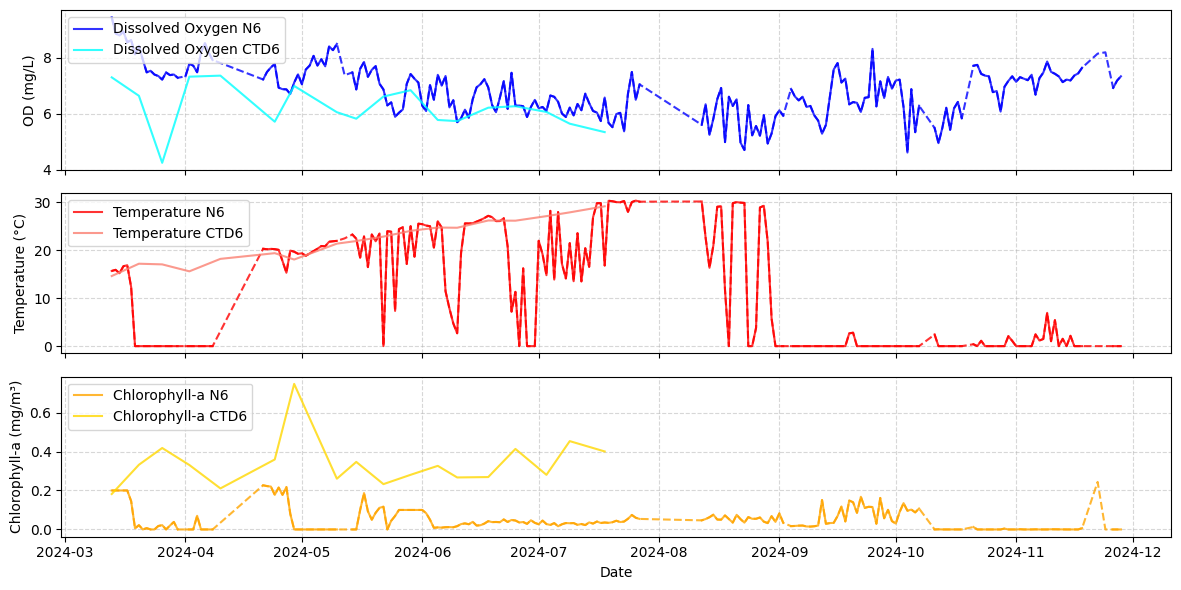

In [24]:
# Select one dataframe from the dictionary
df = dataframes["Pedruchillo"].copy()
df_interpolado = dataframes_interpolados["Pedruchillo"].copy()

# Ensure the index is in datetime format for better plotting
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_interpolado['Date'] = pd.to_datetime(df_interpolado['Date'])
df_interpolado.set_index('Date', inplace=True)

# Define indices for each plot
od_idx = 0
#ec_idx = 1
temp_idx = 1
chlor_idx = 2

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

start_date = df.index[0]
# end_date = dataframes_boya_upct["CTD6_Oxigeno"].index[-1]

#od_upct = dataframes_boya_upct["CTD6_Oxigeno"][(dataframes_boya_upct["CTD6_Oxigeno"].index >= start_date) & (dataframes_boya_upct["CTD6_Oxigeno"].index <= end_date)]
od_upct = dataframes_boya_upct["CTD6_Oxigeno"][dataframes_boya_upct["CTD6_Oxigeno"].index >= start_date]
# ec_upct = dataframes_boya_upct["CTD6_Salinidad"][dataframes_boya_upct["CTD6_Salinidad"].index >= start_date]
temp_upct = dataframes_boya_upct["CTD6_Temperatura"][dataframes_boya_upct["CTD6_Temperatura"].index >= start_date]
chlor_upct = dataframes_boya_upct["CTD6_Clorofila"][dataframes_boya_upct["CTD6_Clorofila"].index >= start_date]

axes[od_idx].plot(df.index, df['OD'], label='Dissolved Oxygen N6', color='blue', alpha=0.8)
axes[od_idx].plot(df_interpolado.index, df_interpolado['OD'], color='blue', alpha=0.8, linestyle = "--")
axes[od_idx].plot(od_upct.index, od_upct["0.5"], label='Dissolved Oxygen CTD6', color='cyan', alpha=0.8)
axes[od_idx].set_ylabel('OD (mg/L)')
axes[od_idx].legend(loc='upper left')
axes[od_idx].grid(True, linestyle='--', alpha=0.5)

axes[temp_idx].plot(df.index, df['Temp'], label='Temperature N6', color='red', alpha=0.8)
axes[temp_idx].plot(df_interpolado.index, df_interpolado['Temp'], color='red', alpha=0.8, linestyle = "--")
axes[temp_idx].plot(temp_upct.index, temp_upct["0.5"], label='Temperature CTD6', color='salmon', alpha=0.8)
axes[temp_idx].set_ylabel('Temperature (°C)')
axes[temp_idx].legend(loc='upper left')
axes[temp_idx].grid(True, linestyle='--', alpha=0.5)

axes[chlor_idx].plot(df.index, df['Chlor'], label='Chlorophyll-a N6', color='orange', alpha=0.8)
axes[chlor_idx].plot(df_interpolado.index, df_interpolado['Chlor'], color='orange', alpha=0.8, linestyle = "--")
axes[chlor_idx].plot(chlor_upct.index, chlor_upct["0.5"], label='Chlorophyll-a CTD6', color='gold', alpha=0.8)
axes[chlor_idx].set_ylabel('Chlorophyll-a (mg/m³)')
axes[chlor_idx].set_xlabel('Date')
axes[chlor_idx].legend(loc='upper left')
axes[chlor_idx].grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()
plt.show()